In [2]:
import pandas as pd

df = pd.read_csv('air_defense_v3.csv')

print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Time of Detection                   500 non-null    object 
 1   Latitude                            500 non-null    float64
 2   Longitude                           500 non-null    float64
 3   Vertical Speed                      500 non-null    float64
 4   Acceleration X                      500 non-null    float64
 5   Acceleration Y                      500 non-null    float64
 6   Acceleration Z                      500 non-null    float64
 7   Bearing Change Rate                 500 non-null    float64
 8   Altitude Change Rate                500 non-null    float64
 9   Signal Strength                     500 non-null    float64
 10  Frequency                           500 non-null    float64
 11  PRI                                 500 non-n

In [6]:
#Handle missing values

print(df.isnull().sum())

df.fillna(method='ffill', inplace=True)

Time of Detection                     0
Latitude                              0
Longitude                             0
Vertical Speed                        0
Acceleration X                        0
Acceleration Y                        0
Acceleration Z                        0
Bearing Change Rate                   0
Altitude Change Rate                  0
Signal Strength                       0
Frequency                             0
PRI                                   0
Pulse Width                           0
Electronic Warfare                    0
IFF Code                              0
Flight Plan                           0
Communication Signals                 0
Weapon Status                         0
Number of Objects in Formation        0
Formation Type                        0
Country of Origin                     0
Object Behavior                       0
Weather Conditions                    0
Time of Day                           0
Geographic Terrain                    0


C:\Users\User\AppData\Local\Temp\ipykernel_12244\3527235336.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [7]:
df.columns

Index(['Time of Detection', 'Latitude', 'Longitude', 'Vertical Speed',
       'Acceleration X', 'Acceleration Y', 'Acceleration Z',
       'Bearing Change Rate', 'Altitude Change Rate', 'Signal Strength',
       'Frequency', 'PRI', 'Pulse Width', 'Electronic Warfare', 'IFF Code',
       'Flight Plan', 'Communication Signals', 'Weapon Status',
       'Number of Objects in Formation', 'Formation Type', 'Country of Origin',
       'Object Behavior', 'Weather Conditions', 'Time of Day',
       'Geographic Terrain', 'Proximity to Sensitive Locations',
       'Current Air Traffic Density', 'Solar Activity', 'Sensor Reliability',
       'Confidence Level (Detection)', 'Confidence Level (Classification)',
       'Number of Sensors Detecting Object', 'Sensor ID'],
      dtype='object')

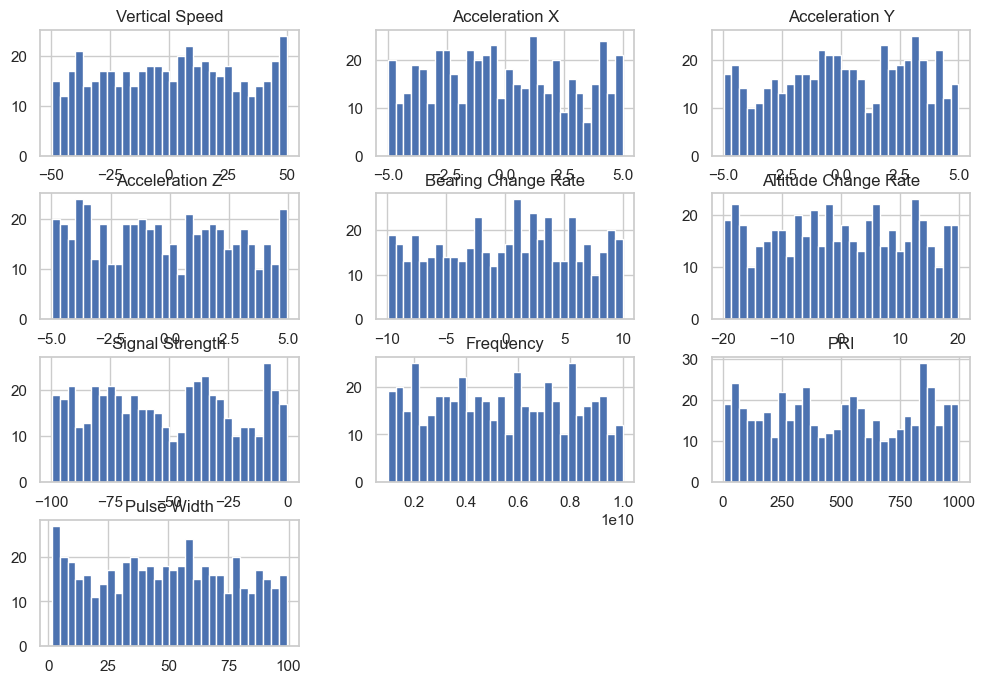

In [13]:
#ditributions of some key features

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

numerical_features = [
    "Vertical Speed", "Acceleration X", "Acceleration Y", "Acceleration Z",
    "Bearing Change Rate", "Altitude Change Rate", "Signal Strength",
    "Frequency", "PRI", "Pulse Width"
]

df[numerical_features].hist(figsize=(12, 8), bins=30)
plt.show()



In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

categorical_columns = [
    'Electronic Warfare', 'IFF Code', 'Flight Plan', 'Communication Signals', 
    'Weapon Status', 'Country of Origin', 'Object Behavior', 'Geographic Terrain', 
    'Formation Type'
]

numerical_columns = [
    'Latitude', 'Longitude', 'Vertical Speed', 'Acceleration X', 'Acceleration Y', 
    'Acceleration Z', 'Bearing Change Rate', 'Altitude Change Rate', 'Signal Strength', 
    'Frequency', 'PRI', 'Pulse Width', 'Number of Objects in Formation', 'Time of Day',
    'Proximity to Sensitive Locations', 'Current Air Traffic Density', 'Solar Activity', 
    'Sensor Reliability', 'Confidence Level (Detection)', 'Confidence Level (Classification)', 
    'Number of Sensors Detecting Object'
]


label_encoder = LabelEncoder()

df['Weapon Status'] = label_encoder.fit_transform(df['Weapon Status'])

df_encoded = pd.get_dummies(df, columns=categorical_columns)

scaler = StandardScaler()

df_encoded[numerical_columns] = scaler.fit_transform(df_encoded[numerical_columns])

print(df_encoded.head())

   Time of Detection  Latitude  Longitude  Vertical Speed  Acceleration X  \
0           1.741316 -0.677850  -1.277907       -1.215709        1.553226   
1           1.741310  1.593975   0.354501        1.415508        1.479426   
2           1.741330 -0.534810  -1.332493       -0.031661        1.486455   
3           1.741317 -0.631894  -0.388931        1.517873       -0.467483   
4           1.741357 -1.577152  -0.213167       -1.084148        0.312686   

   Acceleration Y  Acceleration Z  Bearing Change Rate  Altitude Change Rate  \
0       -0.582058        0.851272            -1.593204              0.138780   
1       -0.542953       -1.642237             0.323064             -1.003737   
2       -1.275289        0.277177            -1.731962             -1.558475   
3       -0.272770       -0.241583            -0.300469             -1.365447   
4        0.669313       -1.158060             0.755147             -0.759409   

   Signal Strength  ...  Country of Origin_9  Object Beh

In [24]:
df.columns

Index(['Time of Detection', 'Latitude', 'Longitude', 'Vertical Speed',
       'Acceleration X', 'Acceleration Y', 'Acceleration Z',
       'Bearing Change Rate', 'Altitude Change Rate', 'Signal Strength',
       'Frequency', 'PRI', 'Pulse Width', 'Electronic Warfare', 'IFF Code',
       'Flight Plan', 'Communication Signals', 'Weapon Status',
       'Number of Objects in Formation', 'Formation Type', 'Country of Origin',
       'Object Behavior', 'Weather Conditions', 'Time of Day',
       'Geographic Terrain', 'Proximity to Sensitive Locations',
       'Current Air Traffic Density', 'Solar Activity', 'Sensor Reliability',
       'Confidence Level (Detection)', 'Confidence Level (Classification)',
       'Number of Sensors Detecting Object', 'Sensor ID', 'Weapn Status'],
      dtype='object')

In [32]:
df['Object Behavior']

0      2
1      2
2      0
3      0
4      0
      ..
495    2
496    0
497    2
498    2
499    2
Name: Object Behavior, Length: 500, dtype: int64

In [35]:
# Ensure all column names are stripped of extra spaces
df_encoded.columns = df_encoded.columns.str.strip()

# Print all column names to verify the issue
print(df_encoded.columns.tolist())

# Check if 'Object Behavior' exists in the cleaned column names
if 'Object Behavior' in df_encoded.columns:
    print("Column 'Object Behavior' exists and is accessible!")
else:
    print("ERROR: Column 'Object Behavior' not found! Here are similar names:")
    
    # Find similar column names in case of hidden characters
    similar_cols = [col for col in df_encoded.columns if 'Object Behavior' in col]
    print(similar_cols)


['Time of Detection', 'Latitude', 'Longitude', 'Vertical Speed', 'Acceleration X', 'Acceleration Y', 'Acceleration Z', 'Bearing Change Rate', 'Altitude Change Rate', 'Signal Strength', 'Frequency', 'PRI', 'Pulse Width', 'Number of Objects in Formation', 'Weather Conditions', 'Time of Day', 'Proximity to Sensitive Locations', 'Current Air Traffic Density', 'Solar Activity', 'Sensor Reliability', 'Confidence Level (Detection)', 'Confidence Level (Classification)', 'Number of Sensors Detecting Object', 'Sensor ID', 'Weapn Status', 'Electronic Warfare_0', 'Electronic Warfare_1', 'Electronic Warfare_2', 'IFF Code_1004', 'IFF Code_1037', 'IFF Code_1060', 'IFF Code_1099', 'IFF Code_1111', 'IFF Code_1120', 'IFF Code_1122', 'IFF Code_1130', 'IFF Code_1140', 'IFF Code_1141', 'IFF Code_1143', 'IFF Code_1163', 'IFF Code_1172', 'IFF Code_1207', 'IFF Code_1236', 'IFF Code_1267', 'IFF Code_1319', 'IFF Code_1326', 'IFF Code_1339', 'IFF Code_1360', 'IFF Code_1375', 'IFF Code_1390', 'IFF Code_1399', 'IF

In [11]:
import pandas as pd

# Print column names with hidden characters for debugging
print("Original Column Names:")
for col in df_encoded.columns:
    print(repr(col))  # Shows hidden spaces, tabs, newlines, etc.

# Step 1: Clean column names (remove spaces, tabs, and hidden characters)
df_encoded.columns = df_encoded.columns.str.strip()  # Remove leading/trailing spaces
df_encoded.columns = df_encoded.columns.str.replace(r'\s+', ' ', regex=True)  # Fix multiple spaces
df_encoded.columns = df_encoded.columns.str.encode('utf-8').str.decode('utf-8')  # Fix encoding issues

# Step 2: Verify if 'Object Behavior' now exists
print("\nCleaned Column Names:")
print(df_encoded.columns.tolist())

# Step 3: If 'Object Behavior' is still missing, find the closest match
for col in df_encoded.columns:
    if 'Object Behavior' in col:
        df_encoded.rename(columns={col: 'Object Behavior'}, inplace=True)
        print(f"Renamed '{col}' to 'Object Behavior'")
        break

# Final check: Ensure 'Object Behavior' exists
if 'Object Behavior' not in df_encoded.columns:
    raise ValueError("ERROR: 'Object Behavior' column still not found!")

# Step 4: Set target variable
target_column = 'Object Behavior'
X = df_encoded.drop(columns=[target_column])  # Features
y = df_encoded[target_column]  # Target variable

# Step 5: Verify successful split
print(f"\n✅ Target Variable Set Successfully!")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"First 5 rows of Target:\n{y.head()}")


Original Column Names:
'Time of Detection'
'Latitude'
'Longitude'
'Vertical Speed'
'Acceleration X'
'Acceleration Y'
'Acceleration Z'
'Bearing Change Rate'
'Altitude Change Rate'
'Signal Strength'
'Frequency'
'PRI'
'Pulse Width'
'Electronic Warfare'
'IFF Code'
'Flight Plan'
'Communication Signals'
'Weapon Status'
'Number of Objects in Formation'
'Formation Type'
'Country of Origin'
'Object Behavior'
'Weather Conditions'
'Time of Day'
'Geographic Terrain'
'Proximity to Sensitive Locations'
'Current Air Traffic Density'
'Solar Activity'
'Sensor Reliability'
'Confidence Level (Detection)'
'Confidence Level (Classification)'
'Number of Sensors Detecting Object'
'Sensor ID'

Cleaned Column Names:
['Time of Detection', 'Latitude', 'Longitude', 'Vertical Speed', 'Acceleration X', 'Acceleration Y', 'Acceleration Z', 'Bearing Change Rate', 'Altitude Change Rate', 'Signal Strength', 'Frequency', 'PRI', 'Pulse Width', 'Electronic Warfare', 'IFF Code', 'Flight Plan', 'Communication Signals', 'Weap

In [10]:
print(f"Final Target Variable: {y.name}")
print(f"Unique Values in Target: {y.unique()}")
print(f"Data Types:\n{df_encoded.dtypes}")


Final Target Variable: Object Behavior
Unique Values in Target: [2 0 1]
Data Types:
Time of Detection                       int64
Latitude                              float64
Longitude                             float64
Vertical Speed                        float64
Acceleration X                        float64
Acceleration Y                        float64
Acceleration Z                        float64
Bearing Change Rate                   float64
Altitude Change Rate                  float64
Signal Strength                       float64
Frequency                             float64
PRI                                   float64
Pulse Width                           float64
Electronic Warfare                     object
IFF Code                                int64
Flight Plan                             int64
Communication Signals                   int64
Weapon Status                           int64
Number of Objects in Formation          int64
Formation Type                         obj

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset (Replace 'your_file.csv' with actual file path)
df = pd.read_csv('air_defense_v3.csv')

# Strip column names to remove leading/trailing spaces
df.columns = df.columns.str.strip()

print('Columns after stripping spaces:')
print(df.columns.tolist())

# Convert 'Time of Detection' to a numeric timestamp
if 'Time of Detection' in df.columns:
    df['Time of Detection'] = pd.to_datetime(df['Time of Detection'], errors='coerce').astype('int64') // 10**9

# Automatically detect categorical columns (non-numeric)
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Detected categorical columns:", categorical_columns)

# Apply Label Encoding to all detected categorical columns
label_encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Define the target variable
target_column = 'Object Behavior'

# Check if target column exists
if target_column not in df.columns:
    raise KeyError(f'Error: Target column "{target_column}" not found in dataset.')

# Define Features (X) and Target (y)
X = df.drop(columns=[target_column])
y = df[target_column]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print(f'Accuracy: {accuracy:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)


Columns after stripping spaces:
['Time of Detection', 'Latitude', 'Longitude', 'Vertical Speed', 'Acceleration X', 'Acceleration Y', 'Acceleration Z', 'Bearing Change Rate', 'Altitude Change Rate', 'Signal Strength', 'Frequency', 'PRI', 'Pulse Width', 'Electronic Warfare', 'IFF Code', 'Flight Plan', 'Communication Signals', 'Weapon Status', 'Number of Objects in Formation', 'Formation Type', 'Country of Origin', 'Object Behavior', 'Weather Conditions', 'Time of Day', 'Geographic Terrain', 'Proximity to Sensitive Locations', 'Current Air Traffic Density', 'Solar Activity', 'Sensor Reliability', 'Confidence Level (Detection)', 'Confidence Level (Classification)', 'Number of Sensors Detecting Object', 'Sensor ID']
Detected categorical columns: ['Electronic Warfare', 'Flight Plan', 'Communication Signals', 'Weapon Status', 'Formation Type', 'Country of Origin', 'Object Behavior', 'Weather Conditions', 'Time of Day', 'Geographic Terrain', 'Solar Activity', 'Sensor ID']
Accuracy: 0.2600
Conf

In [4]:
from sklearn.model_selection import GridSearchCV

#define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#initialize GridSearchCV with RandomForestClassifier
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

#fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

#best parameters found by GridSearchCV
print(f"Best parameters: {grid_search.best_params_}")

#best model
best_rf_model = grid_search.best_estimator_

#evaluate the best model on the test set
y_pred_best = best_rf_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Best model accuracy: {accuracy_best:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best model accuracy: 0.3600


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('air_defense_v3.csv')

print('Dataset Shape: ', df.shape)

print(df.head())

print(df.dtypes)

print(df.isnull().sum())


Dataset Shape:  (500, 33)
            Time of Detection   Latitude   Longitude  Vertical Speed  \
0  2025-03-07 02:50:50.784082 -33.007488 -126.760910          -33.45   
1  2025-03-07 01:08:02.784082  82.568076   45.352674           41.35   
2  2025-03-07 06:38:46.784082 -25.730555 -132.516254            0.21   
3  2025-03-07 03:08:57.784082 -30.669537  -33.031357           44.26   
4  2025-03-07 14:23:56.784082 -78.758096  -14.499615          -29.71   

   Acceleration X  Acceleration Y  Acceleration Z  Bearing Change Rate  \
0            4.33           -1.45            2.27                -8.93   
1            4.12           -1.34           -4.94                 1.98   
2            4.14           -3.40            0.61                -9.72   
3           -1.42           -0.58           -0.89                -1.57   
4            0.80            2.07           -3.54                 4.44   

   Altitude Change Rate  Signal Strength  ...  Time of Day  \
0                  1.53           

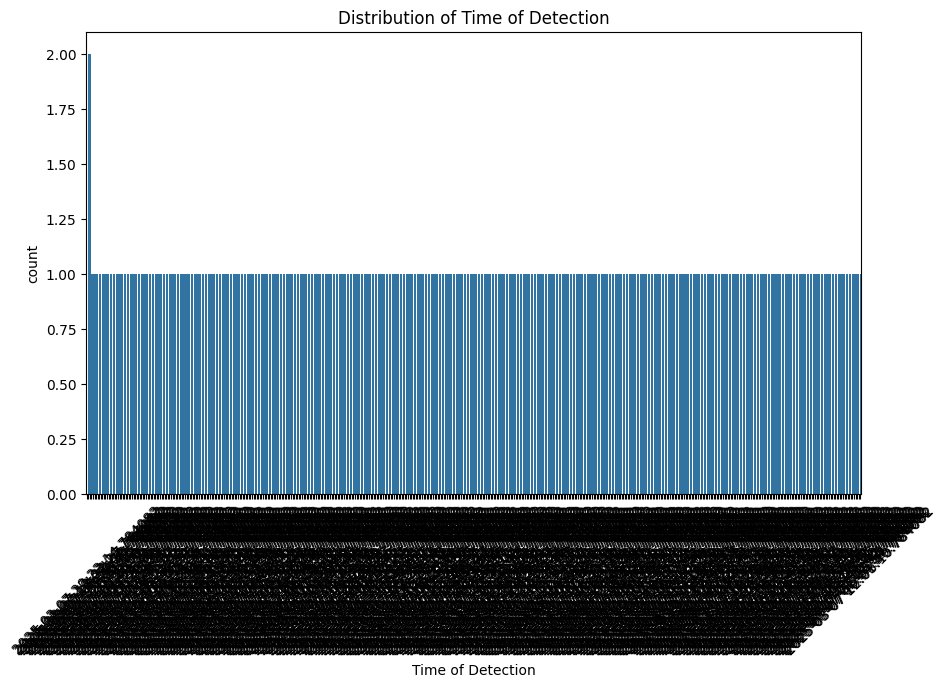

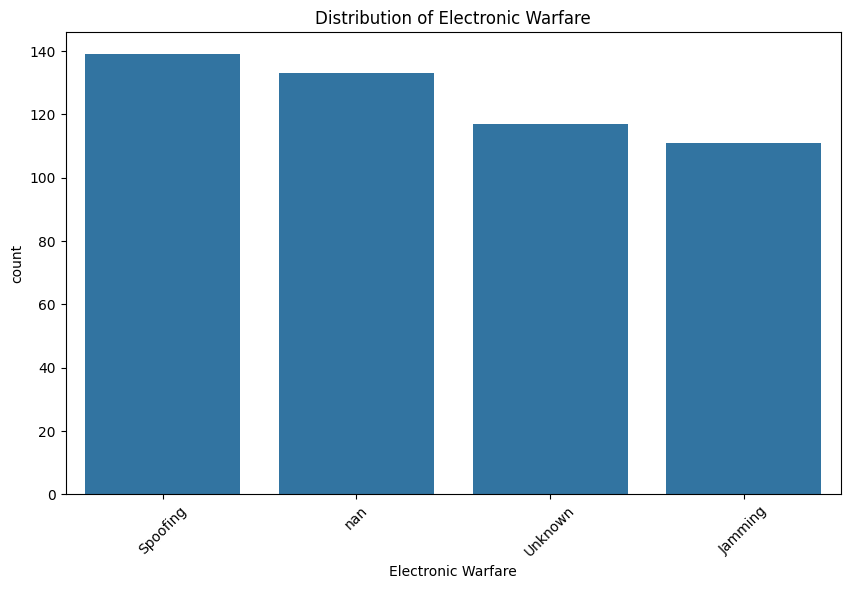

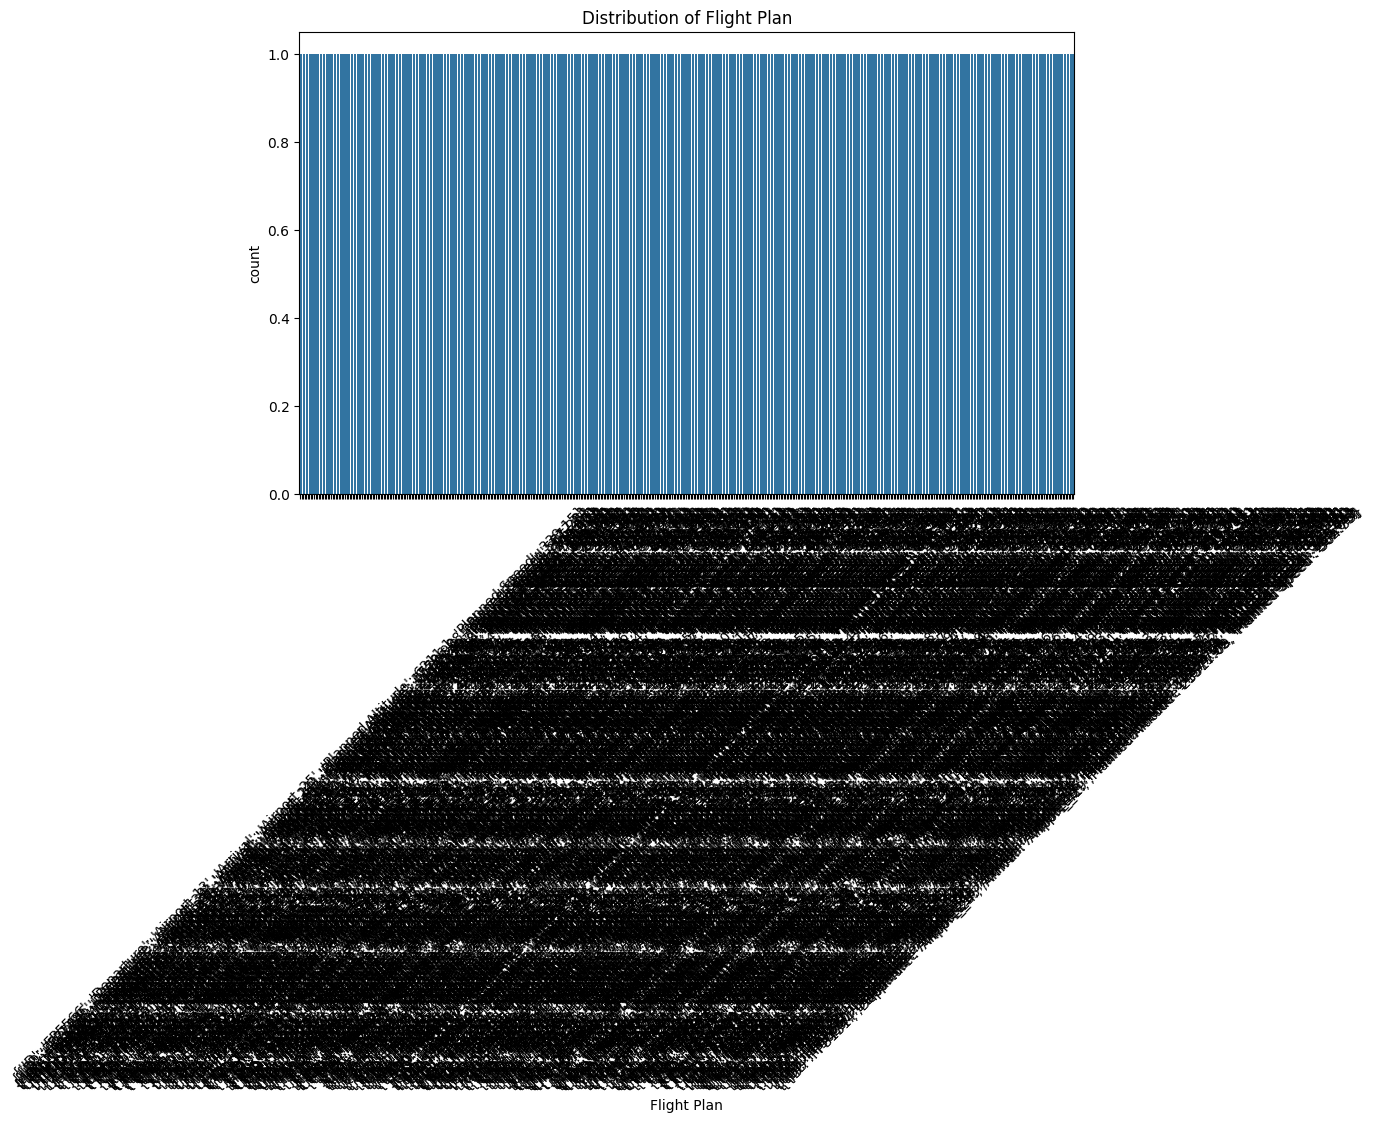

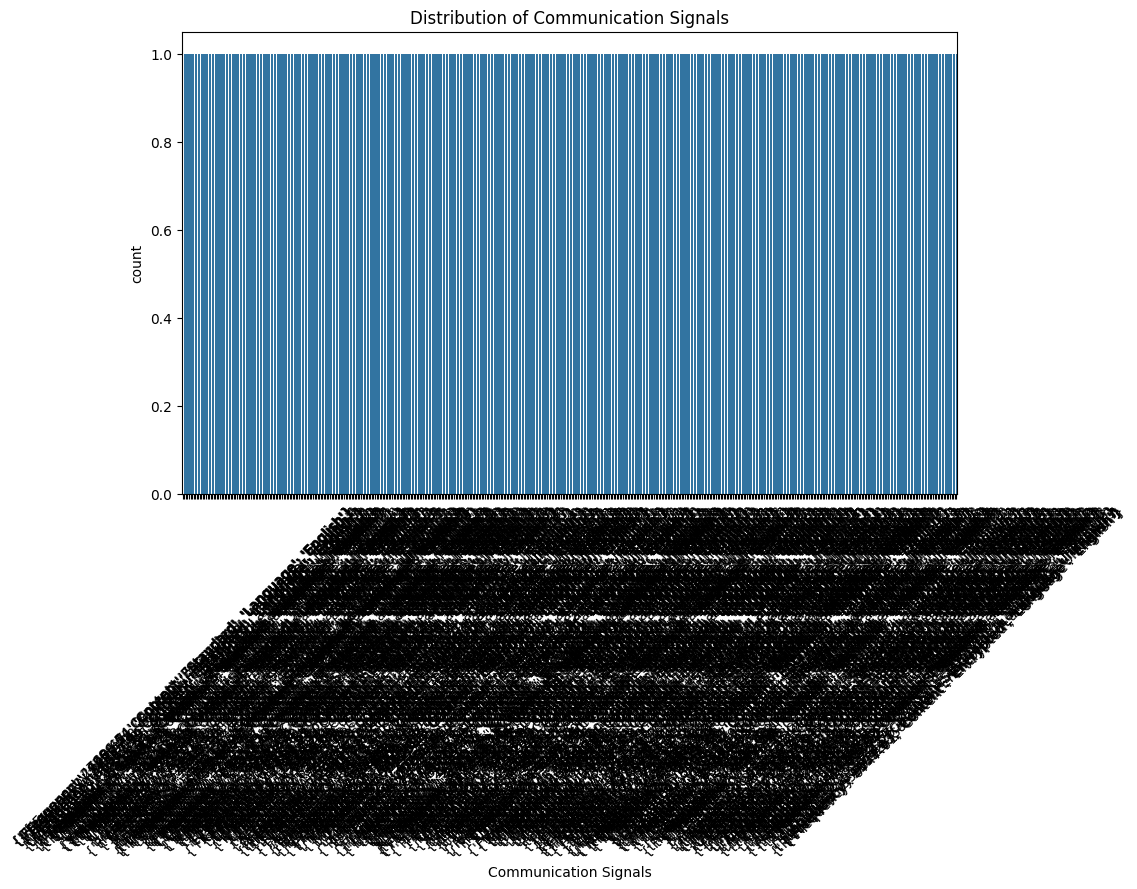

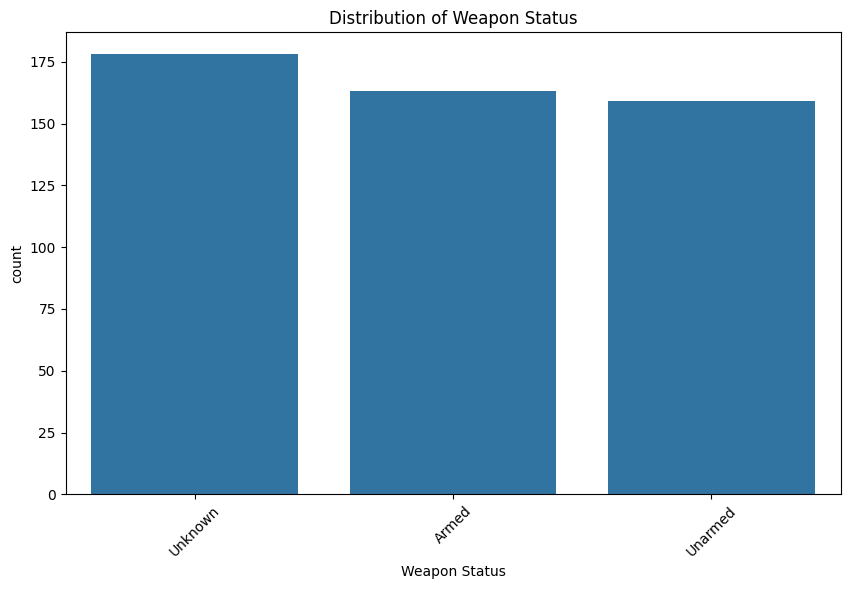

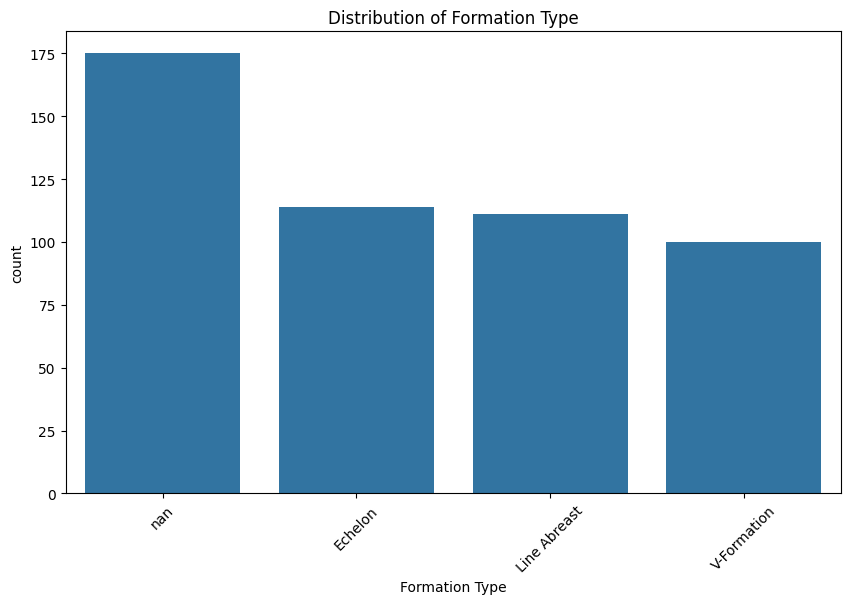

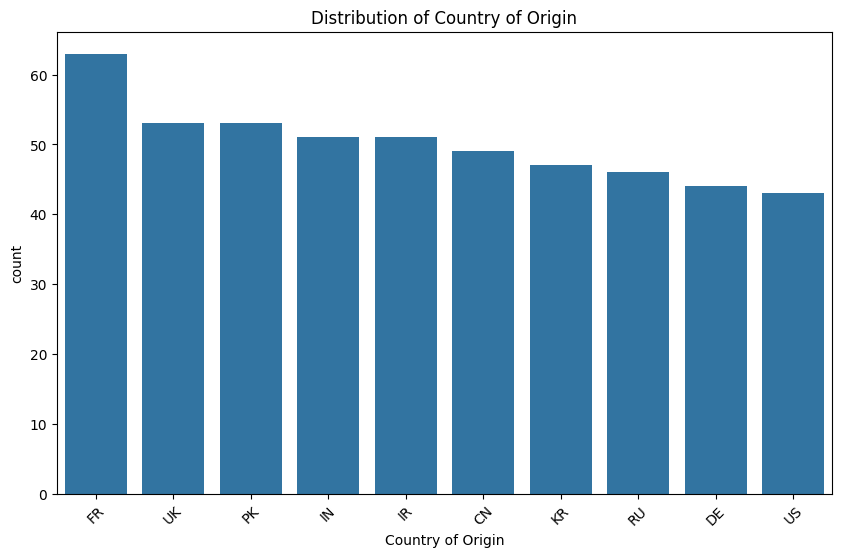

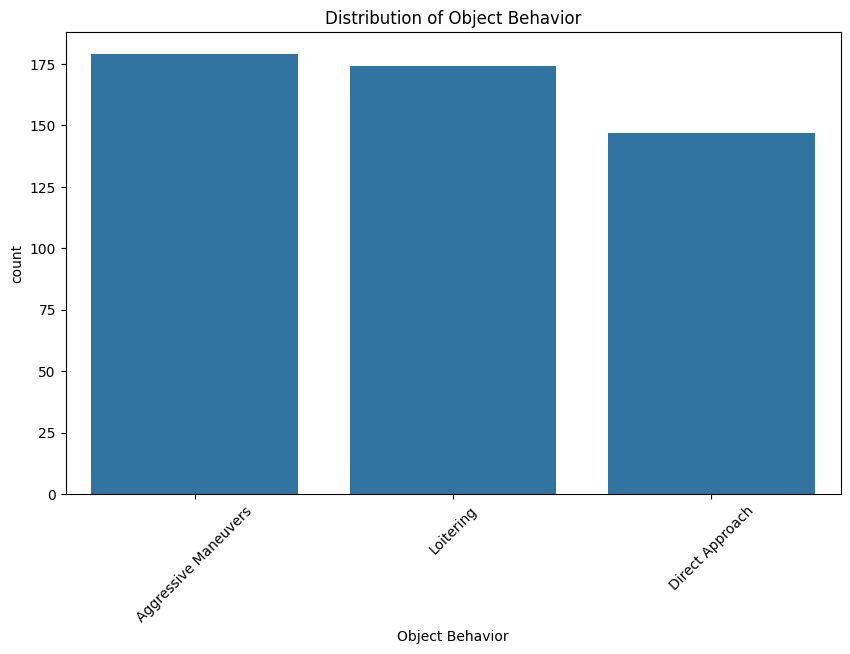

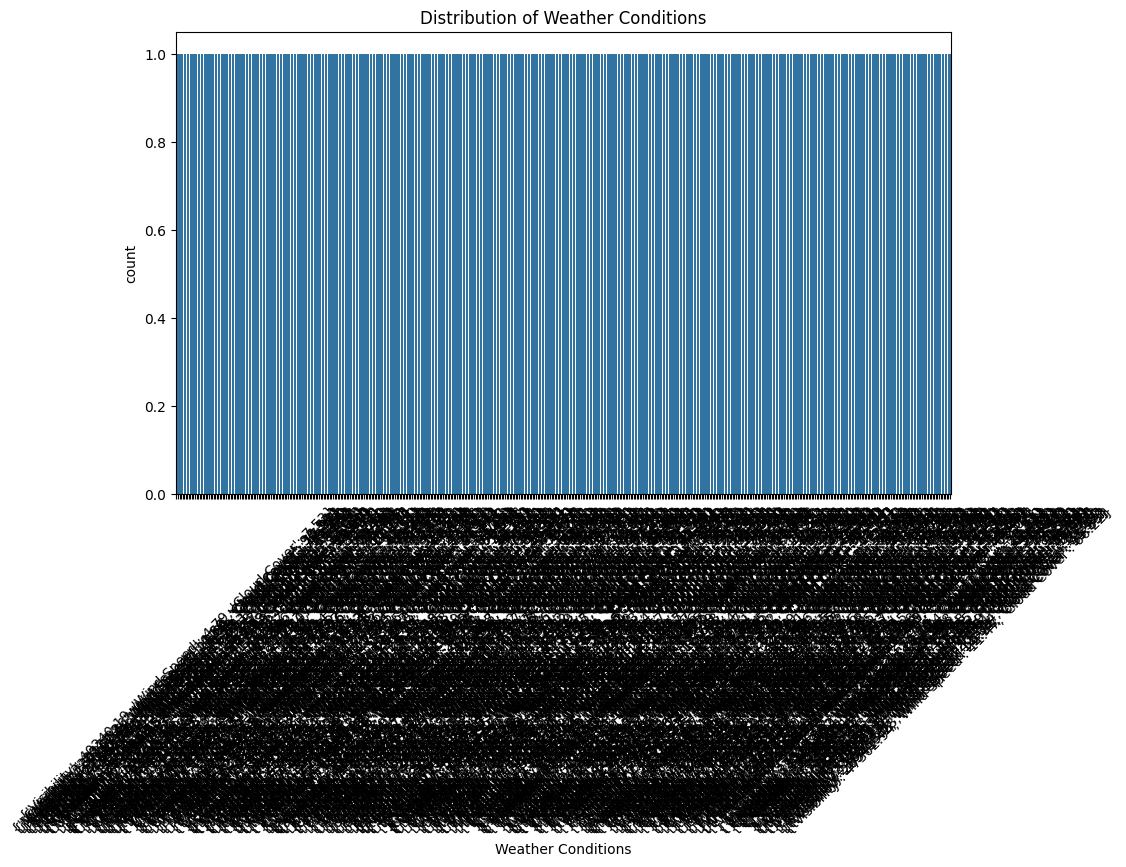

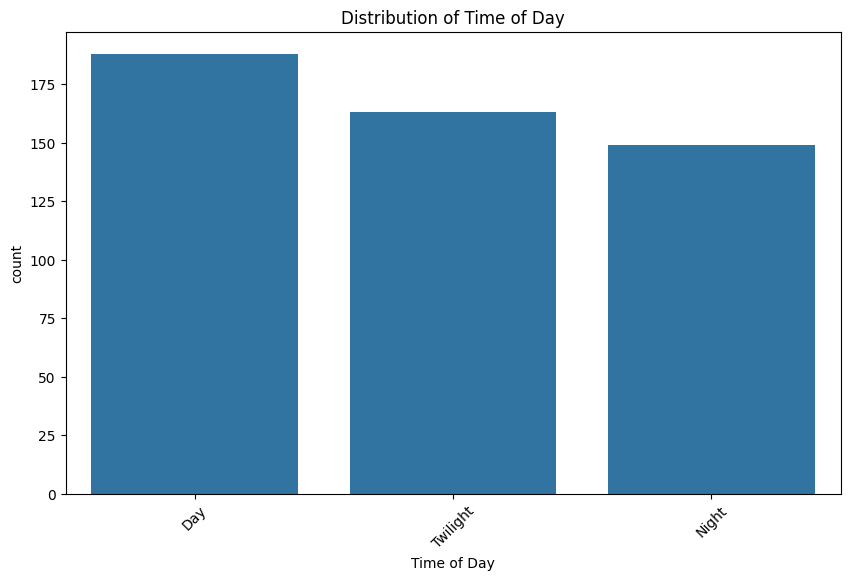

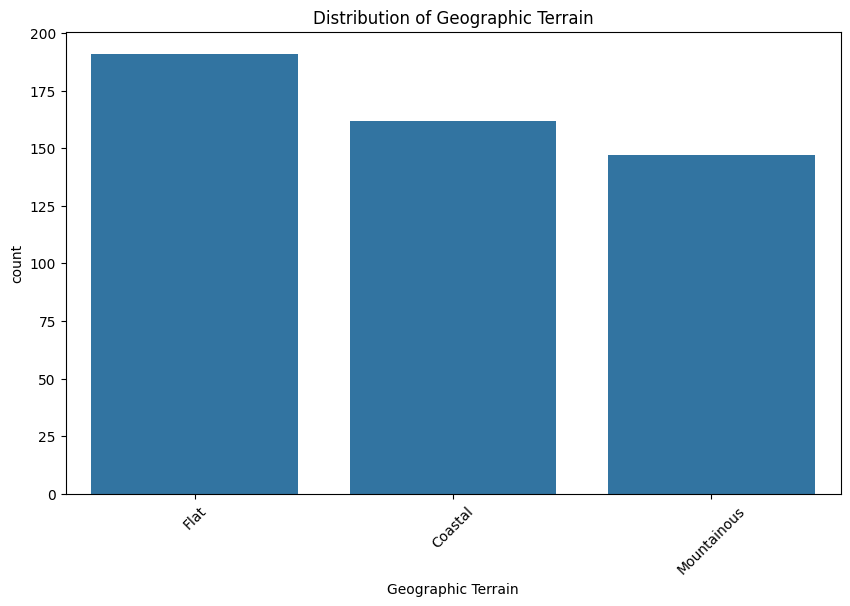

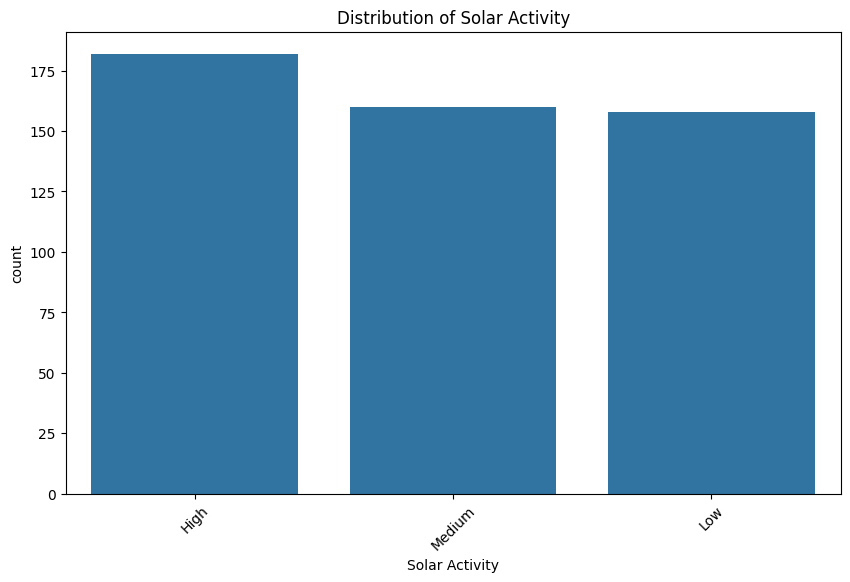

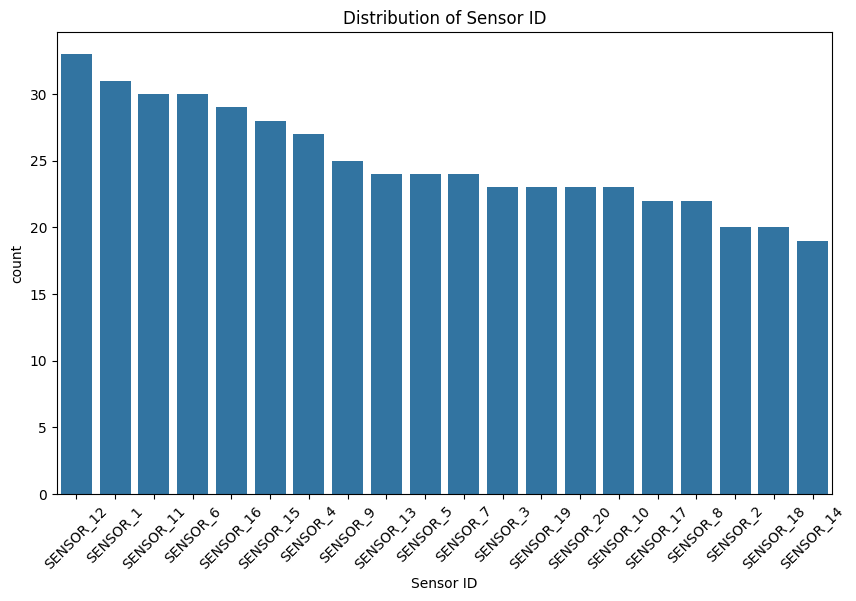

In [14]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Convert all categorical columns to string
df[categorical_columns] = df[categorical_columns].astype(str)

# Plot categorical feature distributions
for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)  # Sort by frequency
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.show()


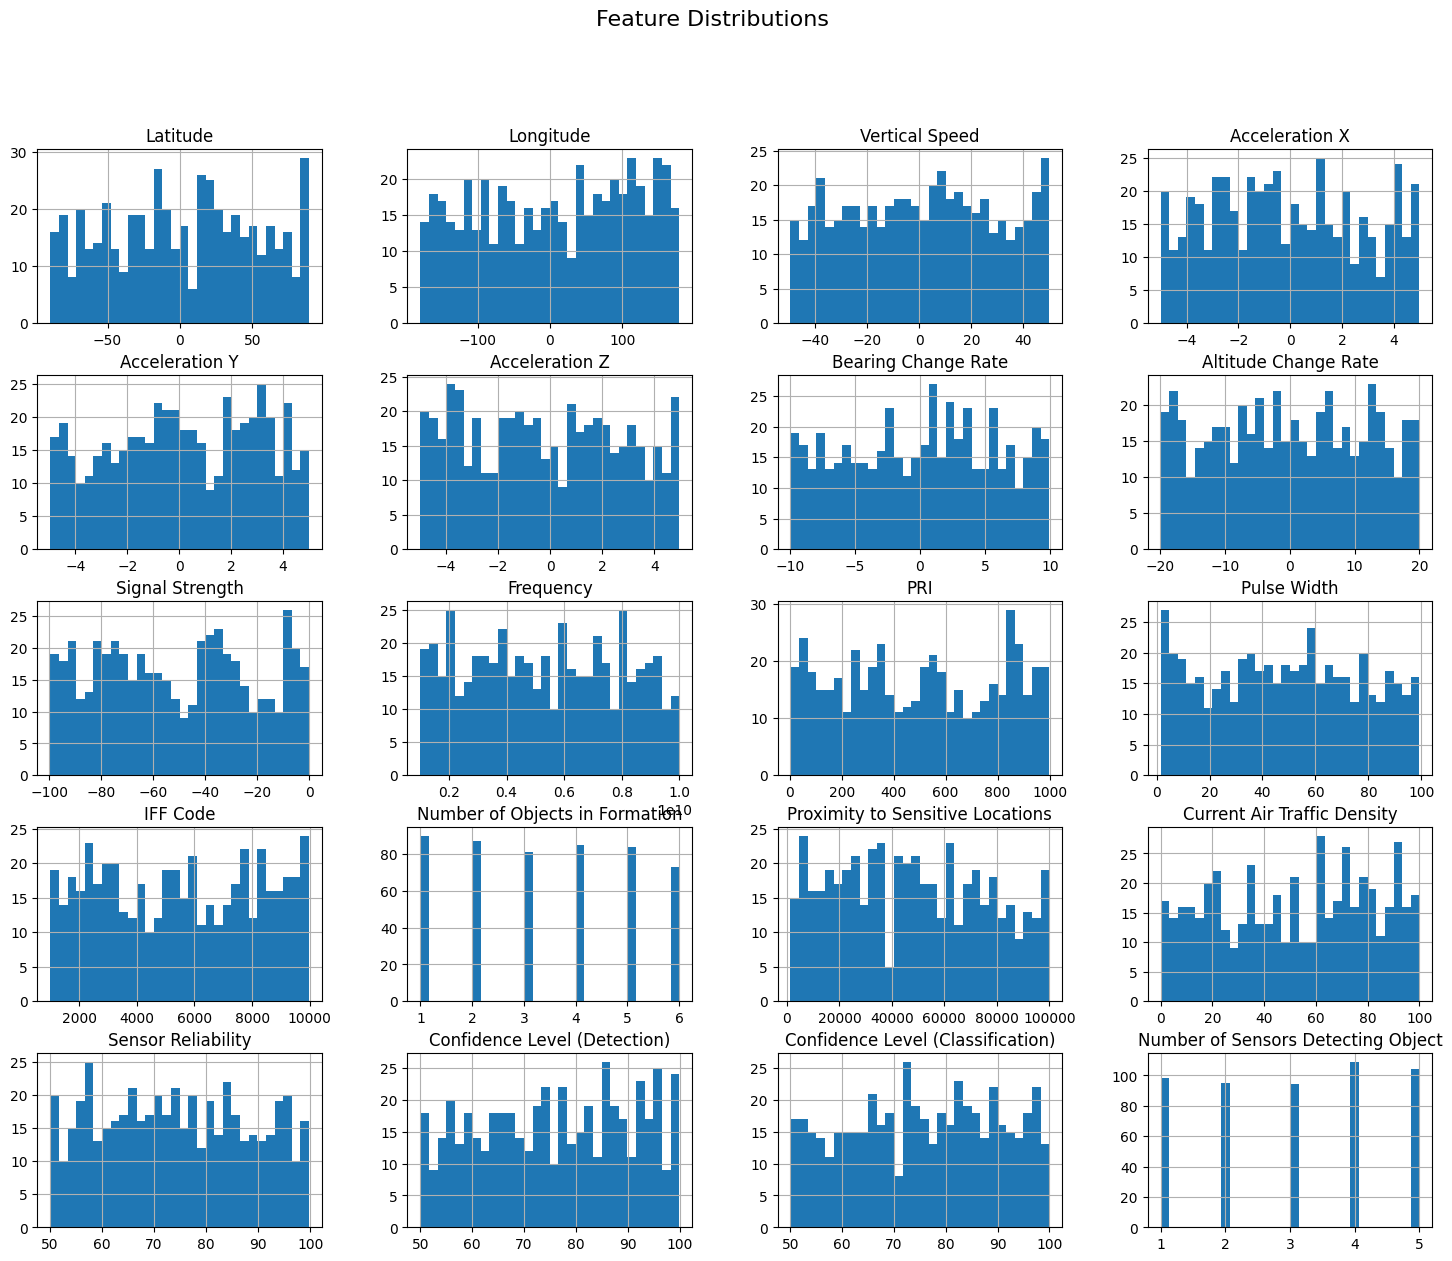

In [19]:
#distribution of numerical features

df.hist(figsize=(18, 14), bins=30)
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()


Non-numeric columns: []


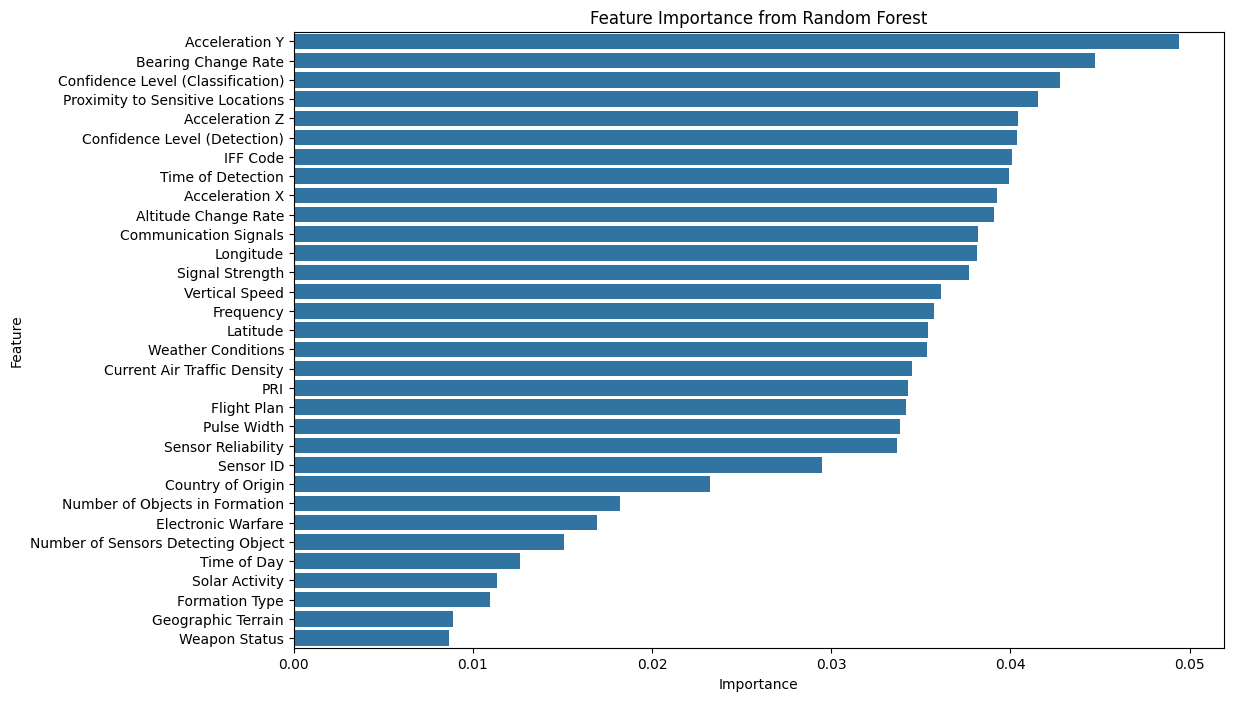

In [25]:
from sklearn.preprocessing import LabelEncoder

#identifying non-numeric columns
non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Non-numeric columns:", non_numeric_columns)

#converting non-numeric columns to categorical using Label Encoding
label_encoders = {}

for col in non_numeric_columns:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le  # Store encoder if needed later

#now, proceed with Random Forest feature importance
importances = rf_model.feature_importances_
feature_names = X.columns  # Ensure X is numeric

#plotting feature importance
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance_df['Importance'], y=feature_importance_df['Feature'])
plt.title('Feature Importance from Random Forest')
plt.show()


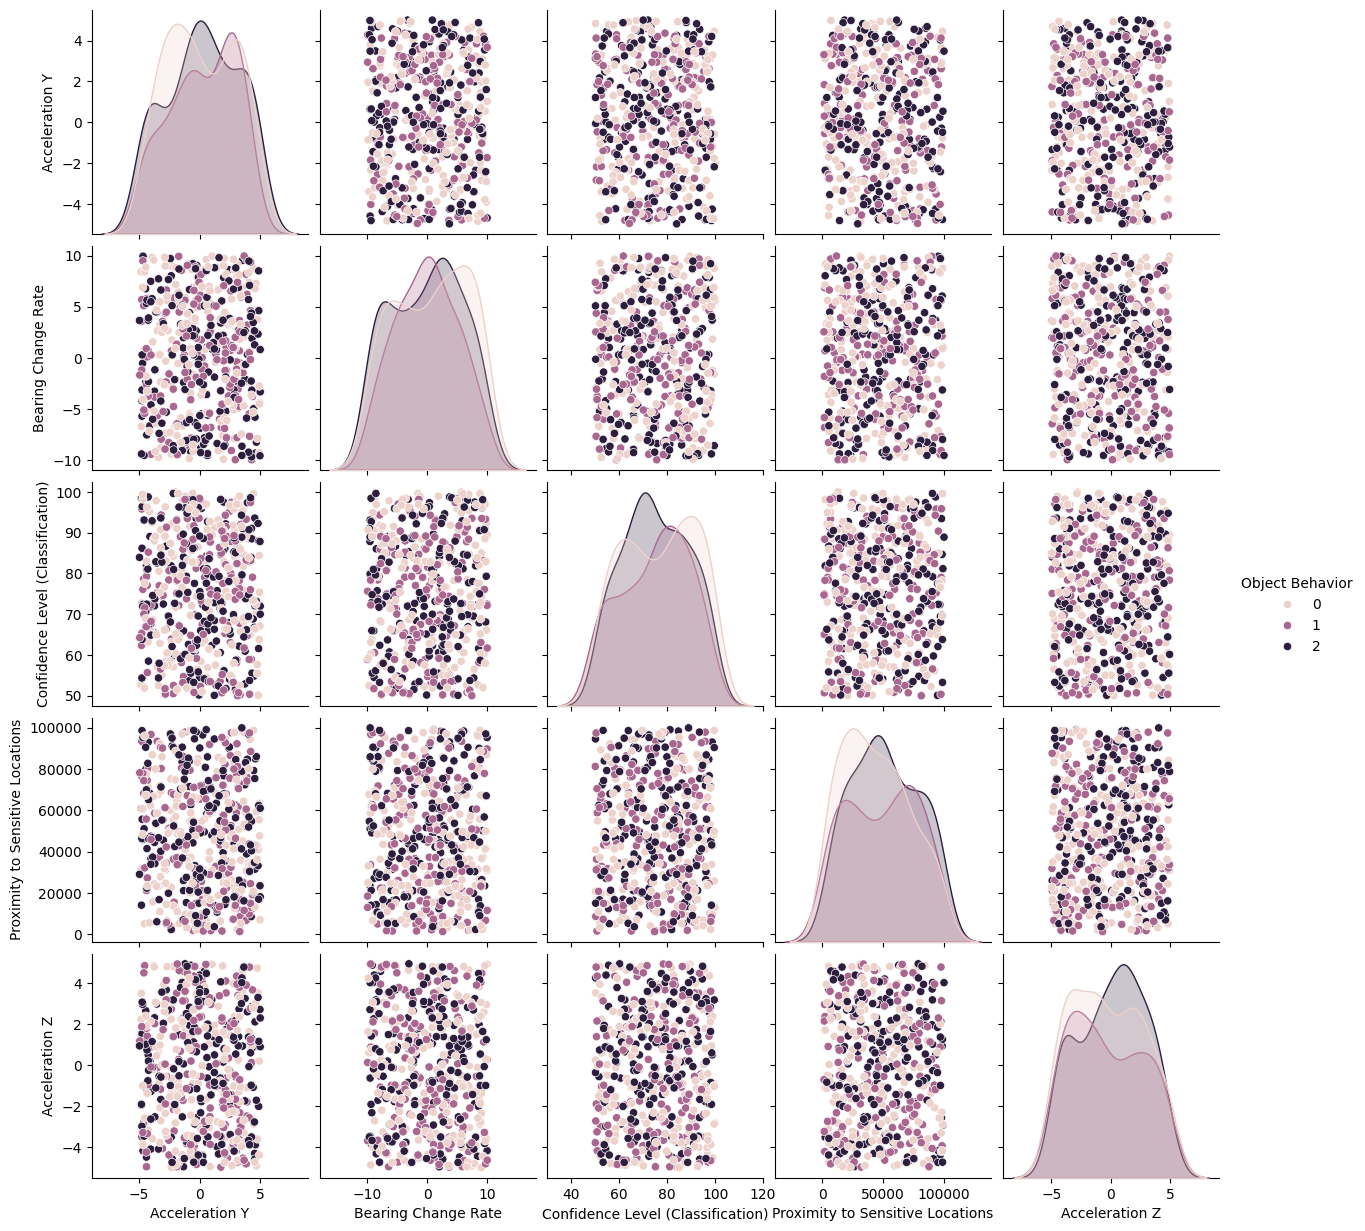

In [29]:
# Select the top 5 most important features
top_features = feature_importance_df['Feature'].head(5).tolist()

# Pair plot for the top features with Object Behavior as hue
sns.pairplot(df[top_features + ['Object Behavior']], hue='Object Behavior', diag_kind='kde')
plt.show()


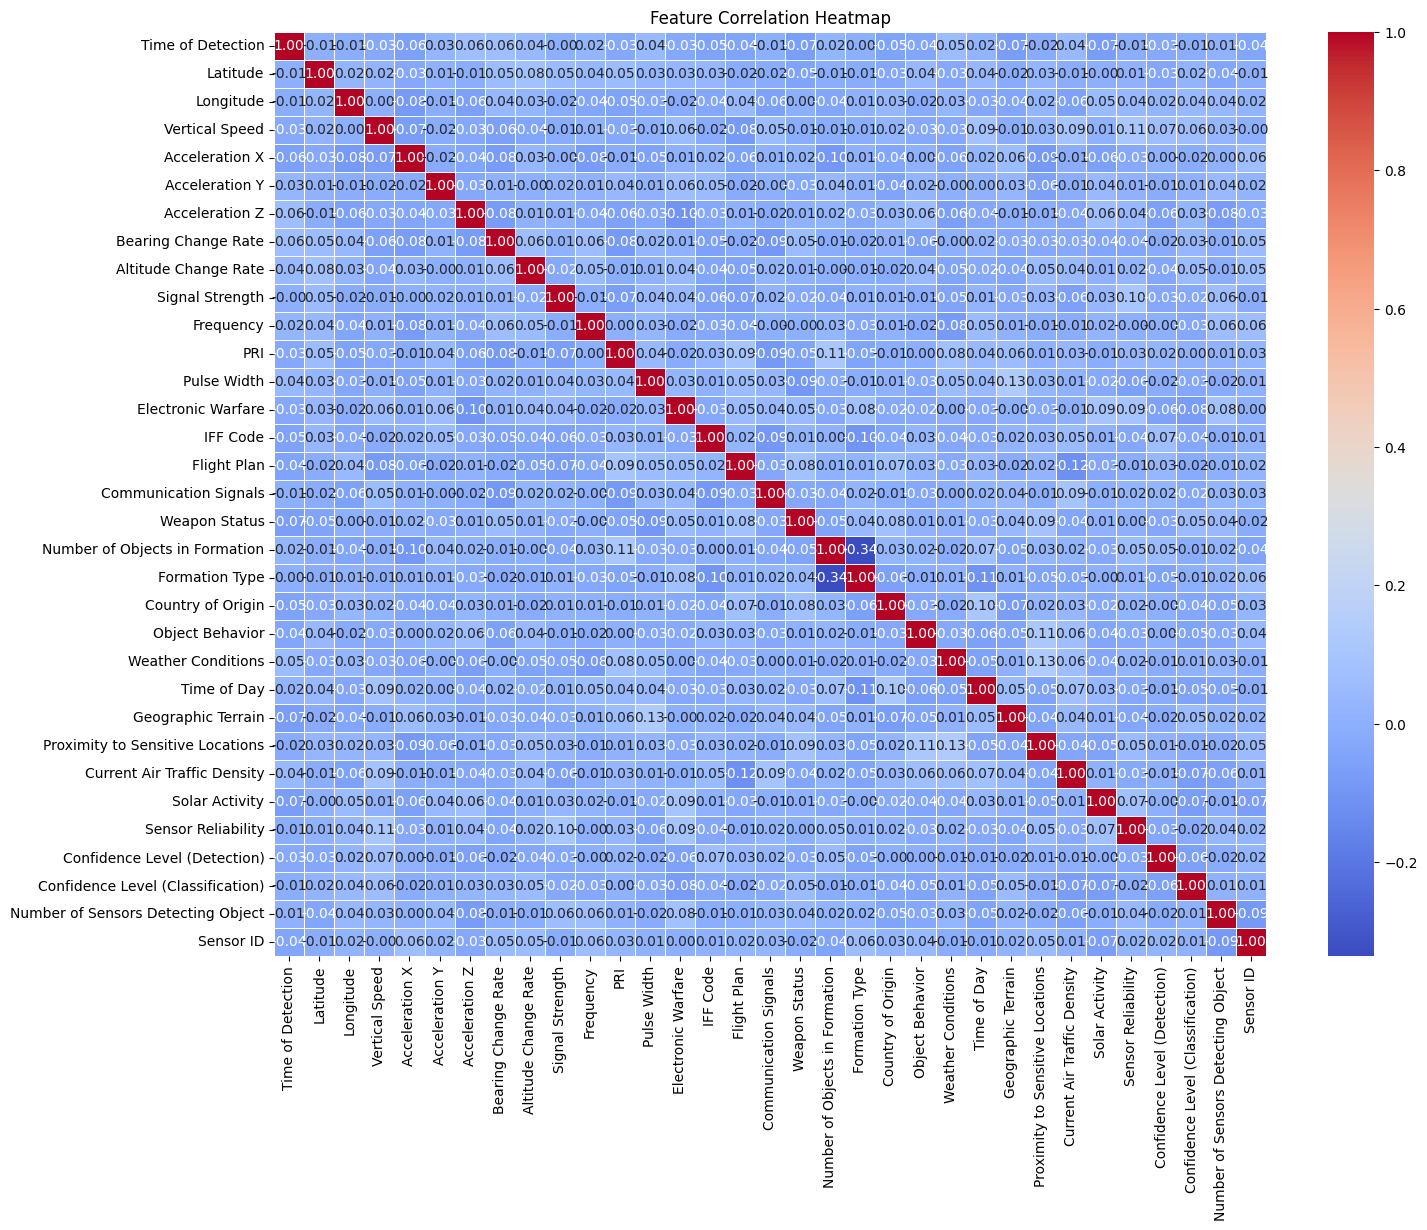

In [31]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

Text(0.5, 1.0, 'Class Distribution of Object Behavior')

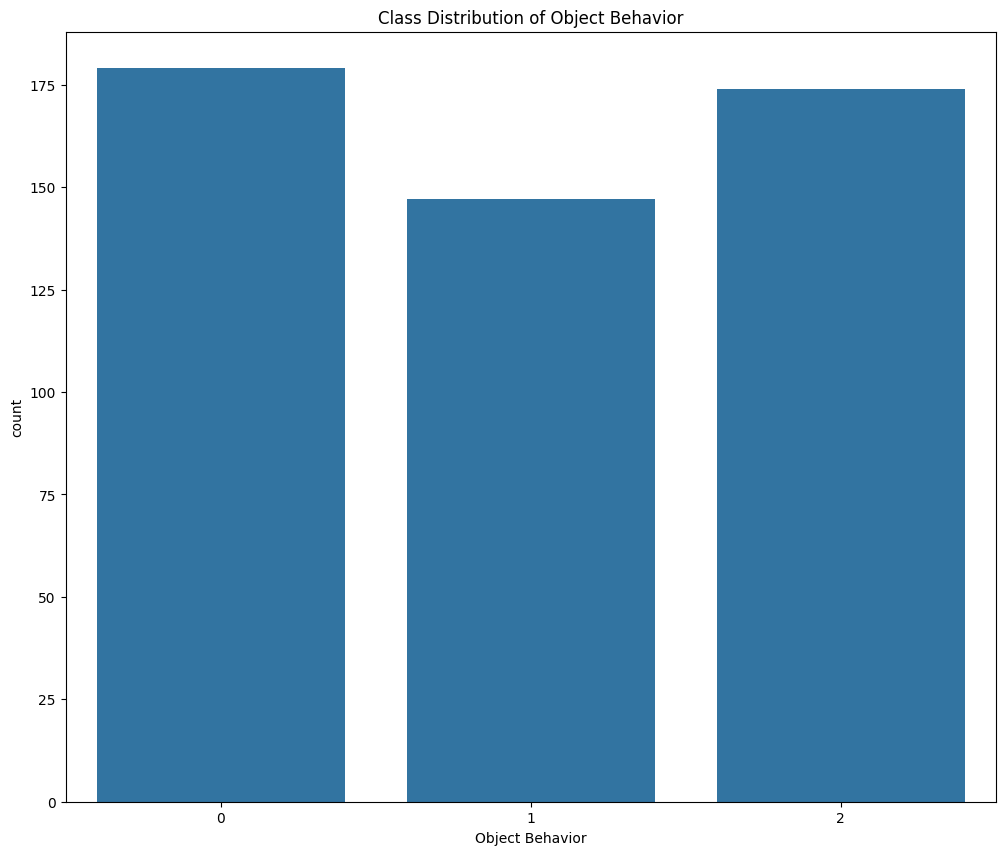

In [33]:
plt.figure(figsize=(12, 10))
sns.countplot(x='Object Behavior', data=df)
plt.title('Class Distribution of Object Behavior')

Text(0.5, 1.0, 'Boxplot of Top Features')

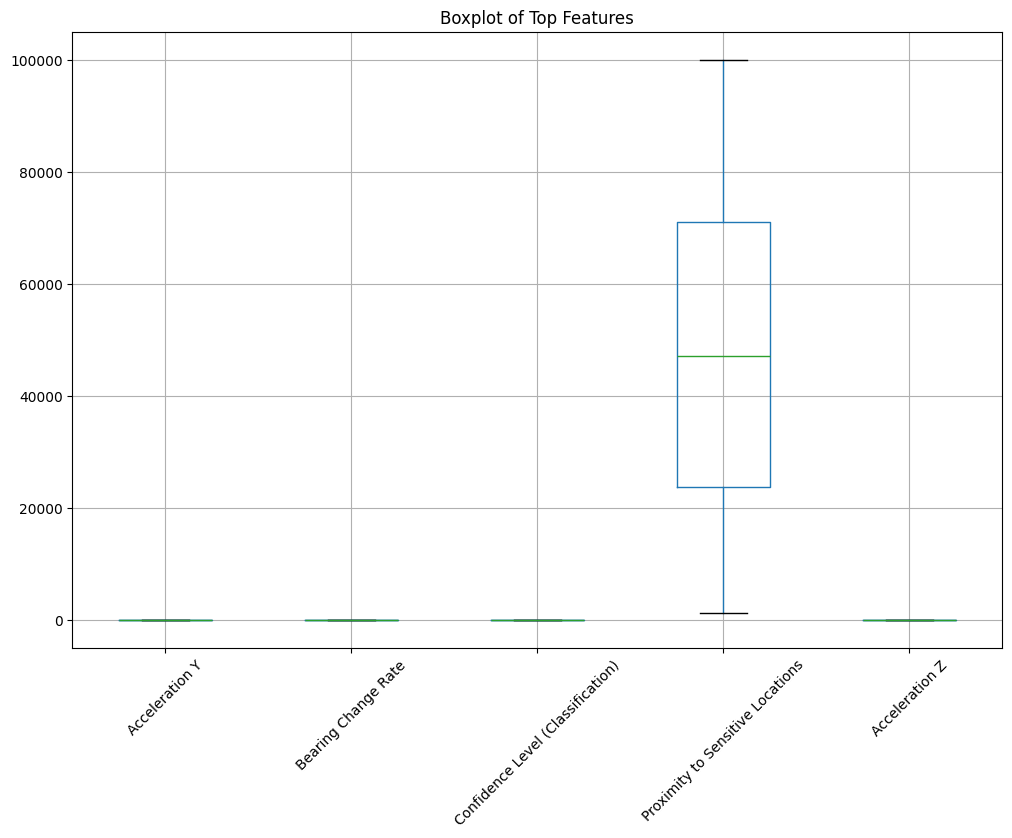

In [ ]:
#box plot to identify outliers

plt.figure(figsize=(12, 8))
df[top_features].boxplot(rot=45)
plt.title('Boxplot of Top')

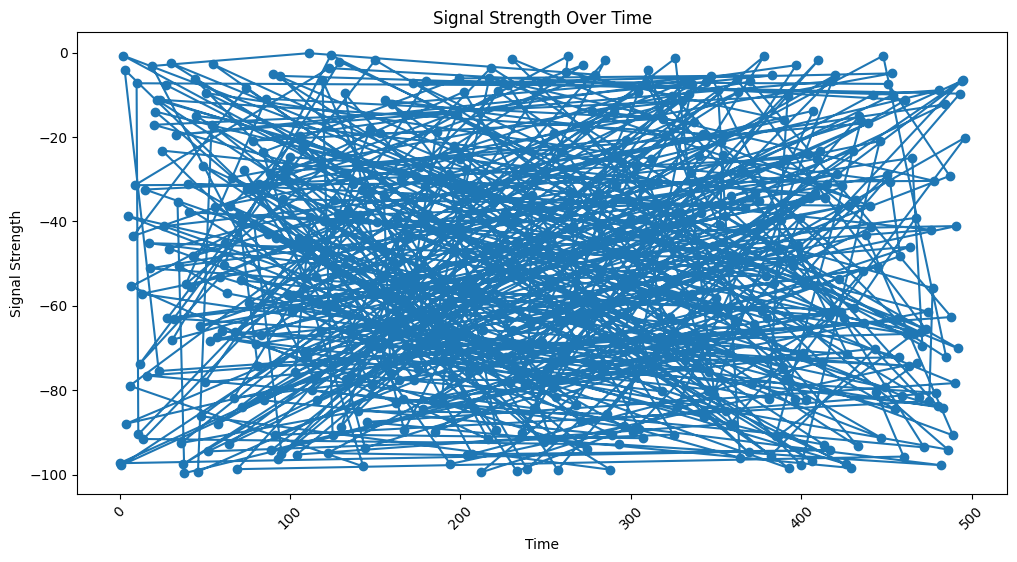

In [39]:


plt.figure(figsize=(12, 6))
plt.plot(df['Time of Detection'], df['Signal Strength'], marker='o', linestyle='-')
plt.title('Signal Strength Over Time')
plt.xlabel('Time')
plt.ylabel('Signal Strength')
plt.xticks(rotation=45)
plt.show()
#identifying sudden spikes in sensor data that may indicate a threat
#Real-World Use Case
#Sudden drop in Signal Strength → Possible electronic warfare (jamming).
#Abrupt increase in Speed/Acceleration → Possible evasive maneuver or missile launch.

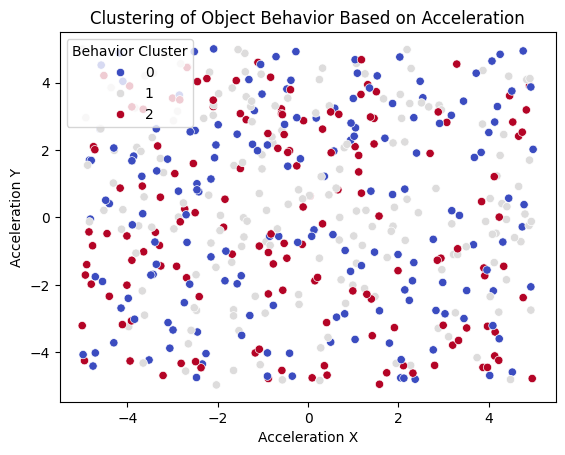

In [40]:
#grouping objects based on behavior patterns and classify potential threats
from sklearn.cluster import KMeans

num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['Behavior Cluster'] = kmeans.fit_predict(df[top_features])

sns.scatterplot(x=df['Acceleration X'], y=df['Acceleration Y'], hue=df['Behavior Cluster'], palette='coolwarm')
plt.title('Clustering of Object Behavior Based on Acceleration')
plt.show()

# Real-World Use Case
#Grouping flight behaviors → Differentiate between civilian aircraft, drones, and enemy jets.
#Identifying swarm tactics → If multiple objects have similar acceleration/altitude patterns, they may be part of a coordinated attack.


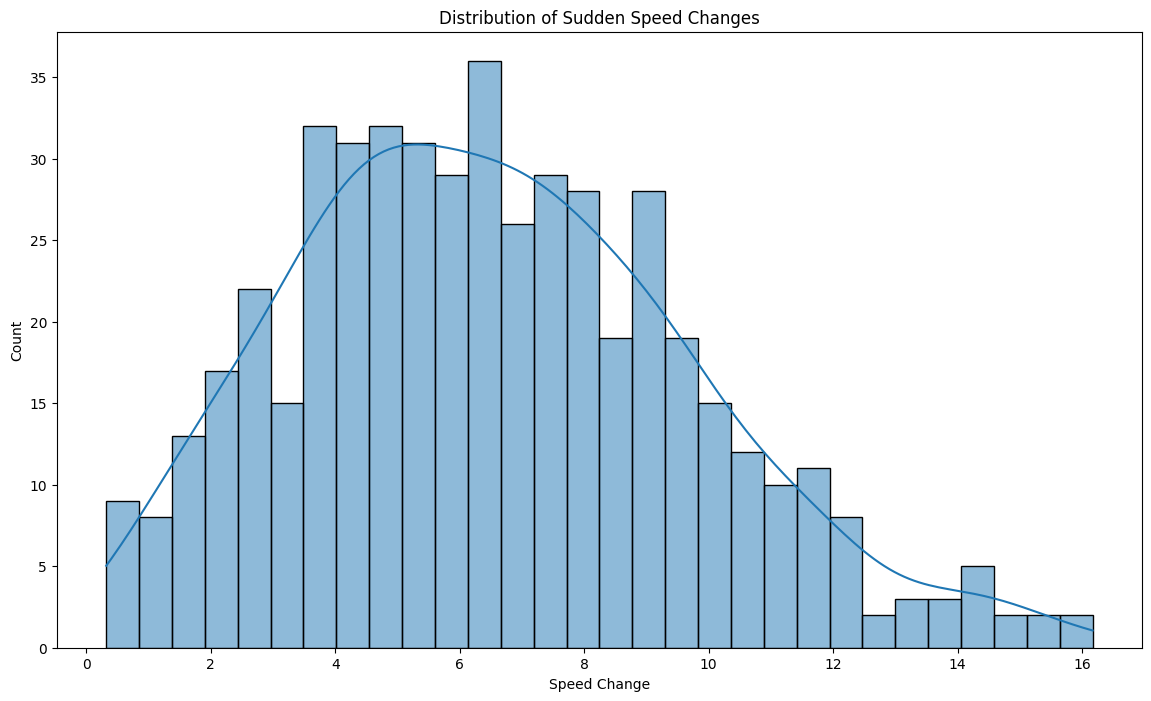

In [42]:
#detecting evasive maneuvers with velocity changes
#goal is to find objects that are suddenly changing direction/speed, possibly indicating hostile intent

df['Speed Change'] = df['Acceleration X'].diff().abs() + df['Acceleration Y'].diff().abs()

plt.figure(figsize=(14, 8))
sns.histplot(df['Speed Change'], bins=30, kde=True)
plt.title('Distribution of Sudden Speed Changes')
plt.show()


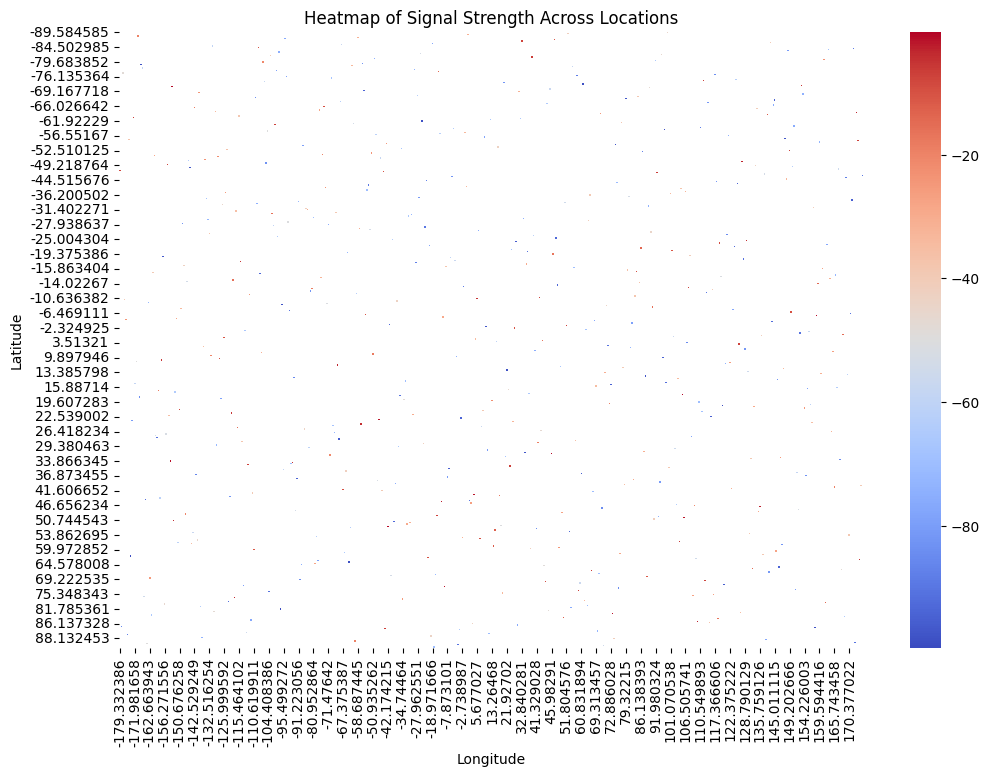

In [ ]:
#heatmap of sensor anomalies across locations
#goal is to identify which locations experience the most sensor interference or high-risk activity

plt.figure(figsize=(12, 8))
sns.heatmap(df.pivot_table(index='Latitude', columns='Longitude', values='Signal Strength'), cmap='coolwarm', annot=False)
plt.title('Heatmap of Signal Strength Across Locations')
plt.show()

#Real-World Use Case
#High interference areas → Could indicate electronic warfare (EW) zones or radar jamming.
#Patterns of object detection → Helps predict where hostile UAVs or enemy aircraft frequently appear.